In [1]:
!pip install pennylane -q

import os, time, copy, json
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pennylane as qml
from PIL import Image, ImageOps, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_curve, auc,
                              roc_auc_score, fbeta_score, classification_report)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 32.1 MB/s eta 0:00:00


In [2]:
!pip install kagglehub -q
import kagglehub

dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
DATA_DIR = os.path.join(dataset_path, "chest_xray", "train")
print("Dataset path:", DATA_DIR)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia/chest_xray/train


In [3]:
IMG_SIZE = 8
N_QUBITS = 8
N_LAYERS = 2

USE_EQUALIZATION = True

def equalize_and_resize(pil_image, img_size=IMG_SIZE):
    img = pil_image.convert("L")
    if USE_EQUALIZATION:
        img = ImageOps.equalize(img)
    img = img.resize((img_size, img_size))
    return np.array(img, dtype=np.float32) / 255.0

def augment_image(pil_image, rng):
    angle = rng.uniform(-8, 8)
    img = pil_image.rotate(angle, fillcolor=0)
    img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.85, 1.15))
    img = ImageEnhance.Contrast(img).enhance(rng.uniform(0.9, 1.1))
    return img

def load_files(files, label, augments=0, seed=0):
    rng = np.random.RandomState(seed)
    X, y = [], []
    for f in files:
        base_img = Image.open(f)
        X.append(equalize_and_resize(base_img))
        y.append(label)
        for _ in range(augments):
            aug = augment_image(base_img.convert("L"), rng)
            X.append(equalize_and_resize(aug))
            y.append(label)
    return X, y

def build_split(data_tuples, augments=0, seed=0):
    X, y = [], []
    for files, label in data_tuples:
        curr_X, curr_y = load_files(files, label, augments=augments, seed=seed)
        X.extend(curr_X)
        y.extend(curr_y)
    return np.array(X), np.array(y)

print("Preprocessing utilities defined.")

Preprocessing utilities defined.


In [4]:
normal_dir = os.path.join(DATA_DIR, "NORMAL")
pneumonia_dir = os.path.join(DATA_DIR, "PNEUMONIA")
n_normal_available = len(glob(os.path.join(normal_dir, "*.jpeg")))
n_pneumonia_available = len(glob(os.path.join(pneumonia_dir, "*.jpeg")))


N_PER_CLASS = min(1000, n_normal_available)
AUGMENTS_PER_IMAGE = 0

normal_files = sorted(glob(os.path.join(normal_dir, "*.jpeg")))[:N_PER_CLASS]
pneu_files = sorted(glob(os.path.join(pneumonia_dir, "*.jpeg")))[:N_PER_CLASS]

n_tr, n_tmp = train_test_split(normal_files, test_size=0.3, random_state=SEED)
n_va, n_te = train_test_split(n_tmp, test_size=0.5, random_state=SEED)
p_tr, p_tmp = train_test_split(pneu_files, test_size=0.3, random_state=SEED)
p_va, p_te = train_test_split(p_tmp, test_size=0.5, random_state=SEED)

X_train, y_train = build_split([(n_tr, 0), (p_tr, 1)], augments=AUGMENTS_PER_IMAGE, seed=SEED)
X_val, y_val = build_split([(n_va, 0), (p_va, 1)], augments=0)
X_test, y_test = build_split([(n_te, 0), (p_te, 1)], augments=0)

Xtr_img_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
Xva_img_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
Xte_img_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
ytr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
yva_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
yte_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"Train (incl. augmentation): {len(Xtr_img_t)} | Val: {len(Xva_img_t)} | Test: {len(Xte_img_t)}")

Train (incl. augmentation): 1400 | Val: 300 | Test: 300


In [5]:
class DeeperHybrid(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_layers=N_LAYERS, dropout_p=0.15):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 8, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        self.pool = nn.AdaptiveAvgPool2d(2)
        self.dropout = nn.Dropout(dropout_p)
        for conv in [self.conv1, self.conv2]:
            nn.init.kaiming_normal_(conv.weight, nonlinearity='relu')
            nn.init.zeros_(conv.bias)
        self.to_qubits = nn.Linear(8 * 2 * 2, n_qubits)

        dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.q_layer = qml.qnn.TorchLayer(circuit, weight_shapes)
        self.classical_head = nn.Linear(n_qubits, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.sigmoid(self.to_qubits(x)) * np.pi
        x = self.q_layer(x)
        return torch.sigmoid(self.classical_head(x))


class BiggerCNN(nn.Module):
    def __init__(self, dropout_p=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 8, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        self.pool = nn.AdaptiveAvgPool2d(2)
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(8 * 2 * 2, 1)
        for conv in [self.conv1, self.conv2]:
            nn.init.kaiming_normal_(conv.weight, nonlinearity='relu')
            nn.init.zeros_(conv.bias)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return torch.sigmoid(self.fc(x))

_hy = DeeperHybrid()
_cn = BiggerCNN()
print("Hybrid params:", sum(p.numel() for p in _hy.parameters()))
print("CNN params:", sum(p.numel() for p in _cn.parameters()))


Hybrid params: 1017
CNN params: 729


In [6]:
def weighted_bce(probs, targets, pos_weight=1.2, eps=1e-7):
    probs = torch.clamp(probs, eps, 1 - eps)
    loss = -(pos_weight * targets * torch.log(probs) + (1 - targets) * torch.log(1 - probs))
    return loss.mean()


def train_model(model, Xtr, ytr, Xva, yva, epochs=80, lr=0.02,
                 batch_size=32, weight_decay=1e-4, pos_weight=1.2,
                 patience=15, min_delta=1e-4, use_scheduler=True,
                 log_every=10, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15) if use_scheduler else None
    n = len(Xtr)
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = Xtr[idx], ytr[idx]
            optimizer.zero_grad()
            out = model(xb)
            loss = weighted_bce(out, yb, pos_weight=pos_weight)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        train_loss = epoch_loss / n
        history["train_loss"].append(train_loss)

        model.eval()
        with torch.no_grad():
            val_loss = weighted_bce(model(Xva), yva, pos_weight=pos_weight).item()
        history["val_loss"].append(val_loss)

        if scheduler:
            scheduler.step(val_loss)
        if verbose and (epoch + 1) % log_every == 0:
            print(f"  Epoch {epoch+1:3d} | train_loss {train_loss:.4f} val_loss {val_loss:.4f}")

        if val_loss < best_val_loss - min_delta:
            best_val_loss, best_state, best_epoch, epochs_no_improve = val_loss, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    return history


def find_best_accuracy_threshold(probs, y_true):
    """Directly optimizes for accuracy, since that's the explicit goal here."""
    best_acc, best_t = 0, 0.5
    for t in np.linspace(0.01, 0.99, 197):
        acc = accuracy_score(y_true, probs > t)
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_acc, best_t

def bag_predict(bagged_models, X_img):
    # Accumulate predictions from all models in the bag
    all_preds = []
    for m in bagged_models:
        m.eval()
        with torch.no_grad():
            # Assuming model output is a single probability, flatten to 1D numpy array
            pred = m(X_img).numpy().flatten()
            all_preds.append(pred)
    # Average the predictions across all models
    return np.mean(all_preds, axis=0)


def benchmark_one_epoch(model_fn, Xtr, ytr, Xva, yva, label, target_epochs=80, batch_size=32):
    model = model_fn()
    start = time.time()
    train_model(model, Xtr, ytr, Xva, yva, epochs=1, patience=999,
                use_scheduler=False, batch_size=batch_size, verbose=False)
    elapsed = time.time() - start
    print(f"[{label}] 1 epoch took {elapsed:.2f}s -> projected {target_epochs} epochs "
          f"= {elapsed*target_epochs/60:.1f} min ({elapsed*target_epochs/3600:.2f} hours)")
    return elapsed


# Moved from cell wX5gIUMHgI2H
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score, matthews_corrcoef,
                              confusion_matrix)

def full_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity_recall": recall_score(y_true, y_pred),
        "specificity": specificity,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred),
        "auc_roc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "confusion_matrix": (tn, fp, fn, tp),
    }

def bootstrap_ci(y_true, y_prob, metric_fn, n_boot=1000, ci=95, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp = np.array(y_true)[idx], np.array(y_prob)[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def bootstrap_diff_ci(y_true, y_prob_a, y_prob_b, n_boot=1000, seed=0):
    """CI for the DIFFERENCE between two models' AUROC on the same test set."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt = np.array(y_true)[idx]
        if len(np.unique(yt)) < 2:
            continue
        diffs.append(roc_auc_score(yt, np.array(y_prob_b)[idx]) - roc_auc_score(yt, np.array(y_prob_a)[idx]))
    mean_diff = np.mean(diffs)
    lo, hi = np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)
    significant = not (lo <= 0 <= hi)   # CI excludes zero -> statistically meaningful difference
    return mean_diff, lo, hi, significant


print("Training utilities defined.")

Training utilities defined.


In [27]:
K = 5
EPOCHS = 100

print("Training bagged Hybrid (quantum) ensemble...")
bagged_models = []
for k in range(K):
    print(f"  Model {k+1}/{K}...")
    torch.manual_seed(SEED * 100 + k)
    m = DeeperHybrid(N_QUBITS, N_LAYERS)
    train_model(m, Xtr_img_t, ytr_t, Xva_img_t, yva_t,
                epochs=EPOCHS, lr=0.02, weight_decay=1e-4, pos_weight=1.0,
                patience=15, use_scheduler=True, verbose=False)
    bagged_models.append(m)

print("\nTraining plain CNN baseline...")
torch.manual_seed(SEED)
cnn_model = BiggerCNN()
train_model(cnn_model, Xtr_img_t, ytr_t, Xva_img_t, yva_t,
            epochs=EPOCHS, lr=0.05, weight_decay=1e-4, pos_weight=1.0,  # <-- changed from 1.2
            patience=15, use_scheduler=True, verbose=False)

Training bagged Hybrid (quantum) ensemble...
  Model 1/5...
  Model 2/5...
  Model 3/5...
  Model 4/5...
  Model 5/5...

Training plain CNN baseline...


{'train_loss': [0.4851132162979671,
  0.37627706970487323,
  0.31892164068562645,
  0.31147012404033114,
  0.2695943638256618,
  0.26813388415745326,
  0.24397367643458504,
  0.2761589871134077,
  0.26250231393745965,
  0.2837105256319046,
  0.2246723358971732,
  0.2605583986214229,
  0.22208482606070382,
  0.2349572667479515,
  0.22025175797087806,
  0.220388132248606,
  0.21891661150114877,
  0.20853647717407772,
  0.20408260192189898,
  0.2084000848872321,
  0.2123435891526086,
  0.23388278101171767,
  0.18284065123115267,
  0.17972169075693403,
  0.195807192836489,
  0.19585623613425662,
  0.1962296256848744,
  0.1963249312341213,
  0.19282626935413905,
  0.18526485847575325,
  0.1762089228630066,
  0.18328634772981917,
  0.18741002534117018,
  0.1723363894862788,
  0.20376748042447226,
  0.1876692180974143,
  0.17245694526604244,
  0.17159140708191054,
  0.17476367826972689,
  0.16210264095238278,
  0.19484245896339417,
  0.17554995255810874,
  0.17570105697427477,
  0.17331743023

In [8]:
y_val_np = yva_t.numpy().flatten().astype(int)
y_test_np = yte_t.numpy().flatten().astype(int)

hybrid_val_probs = bag_predict(bagged_models, Xva_img_t)
# Unpack the tuple to get only the threshold value
_, hybrid_threshold = find_best_accuracy_threshold(hybrid_val_probs, y_val_np)
hybrid_test_probs = bag_predict(bagged_models, Xte_img_t)
hybrid_preds = (hybrid_test_probs > hybrid_threshold).astype(int)
hybrid_acc = accuracy_score(y_test_np, hybrid_preds)
hybrid_auc = roc_auc_score(y_test_np, hybrid_test_probs)

cnn_model.eval()
with torch.no_grad():
    cnn_val_probs = cnn_model(Xva_img_t).numpy().flatten()
    cnn_test_probs = cnn_model(Xte_img_t).numpy().flatten()
# Unpack the tuple to get only the threshold value
_, cnn_threshold = find_best_accuracy_threshold(cnn_val_probs, y_val_np)
cnn_preds = (cnn_test_probs > cnn_threshold).astype(int)
cnn_acc = accuracy_score(y_test_np, cnn_preds)
cnn_auc = roc_auc_score(y_test_np, cnn_test_probs)

print(f"Quantum-Hybrid: acc={hybrid_acc:.3f} auc={hybrid_auc:.3f} threshold={hybrid_threshold:.3f}")
print(f"CNN: acc={cnn_acc:.3f} auc={cnn_auc:.3f} threshold={cnn_threshold:.3f}")

Quantum-Hybrid: acc=0.940 auc=0.993 threshold=0.705
CNN: acc=0.953 auc=0.990 threshold=0.470


In [9]:
def train_bagged_ensemble(K, model_fn, X_train, y_train, X_val, y_val, seed=42, bootstrap=True):
    """bootstrap=True -> TRUE bagging (each model sees a bootstrap resample of
    the training set, matching the statistical definition of bagging).
    bootstrap=False -> multi-seed ensemble (same data, different init/shuffling) --
    use this name, not 'bagging', if you keep this variant."""
    rng = np.random.RandomState(seed)
    models = []
    n = len(X_train)
    for k in range(K):
        torch.manual_seed(seed * 100 + k)
        if bootstrap:
            idx = rng.randint(0, n, n)  # sample WITH replacement -- this is what makes it bagging
            Xk, yk = X_train[idx], y_train[idx]
        else:
            Xk, yk = X_train, y_train
        m = model_fn()
        train_model(m, Xk, yk, X_val, y_val, epochs=100, patience=15)
        models.append(m)
    return models

In [10]:
def cross_ensemble_predict(hybrid_models, cnn_model, X_img, weight_hybrid=0.5):
    hybrid_probs = bag_predict(hybrid_models, X_img)
    cnn_model.eval()
    with torch.no_grad():
        cnn_probs = cnn_model(X_img).numpy().flatten()
    return weight_hybrid * hybrid_probs + (1 - weight_hybrid) * cnn_probs

val_ensemble_probs = cross_ensemble_predict(bagged_models, cnn_model, Xva_img_t, weight_hybrid=0.5)
_, ensemble_threshold = find_best_accuracy_threshold(val_ensemble_probs, y_val_np)

test_ensemble_probs = cross_ensemble_predict(bagged_models, cnn_model, Xte_img_t, weight_hybrid=0.5)
ensemble_preds = (test_ensemble_probs > ensemble_threshold).astype(int)
ensemble_acc = accuracy_score(y_test_np, ensemble_preds)
ensemble_auc = roc_auc_score(y_test_np, test_ensemble_probs)
print(f"Cross-architecture ensemble: acc={ensemble_acc:.3f} auc={ensemble_auc:.3f}")

Cross-architecture ensemble: acc=0.957 auc=0.992


In [11]:
import re

def extract_patient_id(filename):
    """Kaggle pneumonia filenames often encode a patient/case number
    (e.g., 'person1946_bacteria_4874.jpeg' -> patient 1946). Adjust the
    regex if your actual filenames differ."""
    match = re.search(r'person(\d+)', filename)
    return match.group(1) if match else filename  # fallback: treat as unique

all_normal_files = sorted(glob(os.path.join(normal_dir, "*.jpeg")))   # NO [:N_PER_CLASS] cap
all_pneumonia_files = sorted(glob(os.path.join(pneumonia_dir, "*.jpeg")))
print(f"Using ALL available images: {len(all_normal_files)} Normal, {len(all_pneumonia_files)} Pneumonia")

# patient-level split check
from sklearn.model_selection import GroupShuffleSplit

def patient_safe_split(files, test_size=0.15, seed=42):
    patient_ids = [extract_patient_id(os.path.basename(f)) for f in files]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_train, idx_test = next(gss.split(files, groups=patient_ids))
    return [files[i] for i in idx_train], [files[i] for i in idx_test]

def verify_no_patient_leakage(train_files, test_files):
    train_ids = set(extract_patient_id(os.path.basename(f)) for f in train_files)
    test_ids = set(extract_patient_id(os.path.basename(f)) for f in test_files)
    overlap = train_ids & test_ids
    assert len(overlap) == 0, f"LEAKAGE: {len(overlap)} patients appear in both train and test!"
    print(f"Verified: no patient overlap between splits ({len(train_ids)} train patients, {len(test_ids)} test patients)")

Using ALL available images: 1341 Normal, 3875 Pneumonia


In [12]:
class SharedCNNTrunk(nn.Module):
    """Common feature extractor for BOTH models -- the only difference
    between Model A and Model B is the final head."""
    def __init__(self, out_features=8):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1); self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1); self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1); self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, out_features)
        for c in [self.conv1, self.conv2, self.conv3]:
            nn.init.kaiming_normal_(c.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.gap(x).view(x.size(0), -1)
        return torch.tanh(self.fc(x)) * np.pi / 2   # bounded, safe for angle embedding


class ModelA_Classical(nn.Module):
    def __init__(self, trunk, n_features=8):
        super().__init__()
        self.trunk = trunk
        self.head = nn.Sequential(nn.Linear(n_features, 8), nn.ReLU(), nn.Linear(8, 1))
    def forward(self, x):
        return torch.sigmoid(self.head(self.trunk(x)))


def make_quantum_head(n_qubits, n_layers, use_entanglement=True):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        if use_entanglement:
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        else:
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RY(weights[l, i, 0], wires=i)
                    qml.RZ(weights[l, i, 1], wires=i)
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": (n_layers, n_qubits, 3 if use_entanglement else 2)}
    return qml.qnn.TorchLayer(circuit, weight_shapes)


class ModelB_Quantum(nn.Module):
    def __init__(self, trunk, n_qubits=8, n_layers=2, use_entanglement=True):
        super().__init__()
        self.trunk = trunk
        self.q_layer = make_quantum_head(n_qubits, n_layers, use_entanglement)
        self.head = nn.Linear(n_qubits, 1)
    def forward(self, x):
        feats = self.trunk(x)
        return torch.sigmoid(self.head(self.q_layer(feats)))

In [13]:
cnn_model.eval()
with torch.no_grad():
    cnn_train_probs = cnn_model(Xtr_img_t).detach().numpy().flatten()

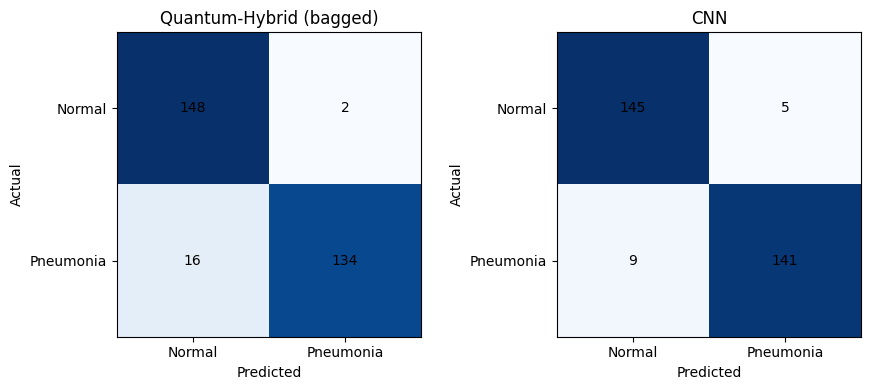

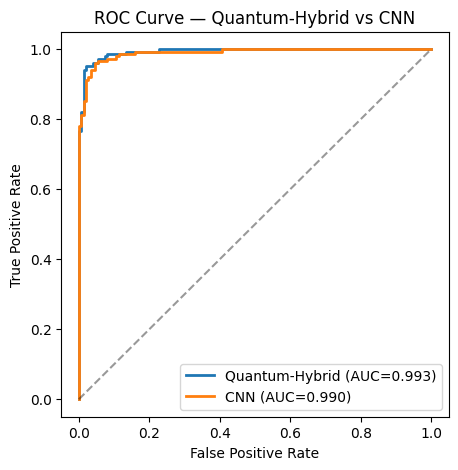

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, preds, name in zip(axes, [hybrid_preds, cnn_preds], ["Quantum-Hybrid (bagged)", "CNN"]):
    cm = confusion_matrix(y_test_np, preds)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Pneumonia"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Pneumonia"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()

fpr_h, tpr_h, _ = roc_curve(y_test_np, hybrid_test_probs)
fpr_c, tpr_c, _ = roc_curve(y_test_np, cnn_test_probs)
plt.figure(figsize=(5, 5))
plt.plot(fpr_h, tpr_h, label=f"Quantum-Hybrid (AUC={hybrid_auc:.3f})", linewidth=2)
plt.plot(fpr_c, tpr_c, label=f"CNN (AUC={cnn_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Quantum-Hybrid vs CNN")
plt.legend(); plt.show()


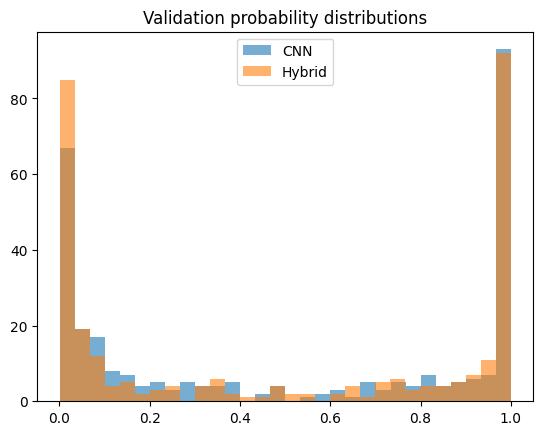

In [15]:
import matplotlib.pyplot as plt
plt.hist(cnn_val_probs, bins=30, alpha=0.6, label="CNN")
plt.hist(hybrid_val_probs, bins=30, alpha=0.6, label="Hybrid")
plt.legend(); plt.title("Validation probability distributions")
plt.show()

In [16]:
def find_threshold(probs, y_true, beta=1.0):
    """Optimizes for F-beta score, with `beta` controlling the weight of precision vs recall."""
    best_fbeta, best_t = 0, 0.5
    for t in np.linspace(0.01, 0.99, 197):
        fbeta = fbeta_score(y_true, probs > t, beta=beta)
        if fbeta > best_fbeta:
            best_fbeta, best_t = fbeta, t
    return best_t

def run_full_pipeline(seed, K_bag=5, epochs=EPOCHS):
    torch.manual_seed(seed); np.random.seed(seed)

    n_tr_s, n_tmp_s = train_test_split(normal_files, test_size=0.3, random_state=seed)
    n_va_s, n_te_s = train_test_split(n_tmp_s, test_size=0.5, random_state=seed)
    p_tr_s, p_tmp_s = train_test_split(pneu_files, test_size=0.3, random_state=seed)
    p_va_s, p_te_s = train_test_split(p_tmp_s, test_size=0.5, random_state=seed)

    Xtr_s, ytr_s = build_split([(n_tr_s, 0), (p_tr_s, 1)], augments=AUGMENTS_PER_IMAGE, seed=seed)
    Xva_s, yva_s = build_split([(n_va_s, 0), (p_va_s, 1)], augments=0)
    Xte_s, yte_s = build_split([(n_te_s, 0), (p_te_s, 1)], augments=0)

    Xtr_st = torch.tensor(Xtr_s, dtype=torch.float32).unsqueeze(1)
    Xva_st = torch.tensor(Xva_s, dtype=torch.float32).unsqueeze(1)
    Xte_st = torch.tensor(Xte_s, dtype=torch.float32).unsqueeze(1)
    ytr_st = torch.tensor(ytr_s, dtype=torch.float32).unsqueeze(1)
    yva_st = torch.tensor(yva_s, dtype=torch.float32).unsqueeze(1)
    yte_st = torch.tensor(yte_s, dtype=torch.float32).unsqueeze(1)

    # --- Bagged Hybrid, matching current best config ---
    models_s = []
    for k in range(K_bag):
        torch.manual_seed(seed * 100 + k)
        m = DeeperHybrid(N_QUBITS, N_LAYERS)   # or DeeperHybrid if you adopted it
        train_model(m, Xtr_st, ytr_st, Xva_st, yva_st, epochs=epochs,
                    pos_weight=1.0, patience=15, use_scheduler=True, verbose=False)  # matches current
        models_s.append(m)

    val_p = bag_predict(models_s, Xva_st)
    y_val_s = yva_st.numpy().flatten().astype(int)
    _, thresh_h = find_best_accuracy_threshold(val_p, y_val_s)   # matches current -- NOT beta-based
    test_p = bag_predict(models_s, Xte_st)
    y_t = yte_st.numpy().flatten().astype(int)
    hybrid_acc_s = accuracy_score(y_t, test_p > thresh_h)
    hybrid_auc_s = roc_auc_score(y_t, test_p)

    # --- CNN, matching current best config ---
    torch.manual_seed(seed)
    cnn_s = BiggerCNN()   # matches current -- NOT SmallCNN
    train_model(cnn_s, Xtr_st, ytr_st, Xva_st, yva_st, epochs=epochs,
                pos_weight=1.0, patience=15, use_scheduler=True, verbose=False)
    cnn_s.eval()
    with torch.no_grad():
        cnn_val_p = cnn_s(Xva_st).numpy().flatten()
        cnn_test_p = cnn_s(Xte_st).numpy().flatten()
    _, thresh_c = find_best_accuracy_threshold(cnn_val_p, y_val_s)
    cnn_acc_s = accuracy_score(y_t, cnn_test_p > thresh_c)
    cnn_auc_s = roc_auc_score(y_t, cnn_test_p)

    # --- Cross-architecture ensemble, matching current best config ---
    val_ens_p = 0.5 * val_p + 0.5 * cnn_val_p
    _, thresh_ens = find_best_accuracy_threshold(val_ens_p, y_val_s)
    test_ens_p = 0.5 * test_p + 0.5 * cnn_test_p
    ens_acc_s = accuracy_score(y_t, test_ens_p > thresh_ens)
    ens_auc_s = roc_auc_score(y_t, test_ens_p)

    print(f"Seed {seed}: Hybrid acc={hybrid_acc_s:.3f} | CNN acc={cnn_acc_s:.3f} | Ensemble acc={ens_acc_s:.3f}")
    return {"seed": seed, "hybrid_acc": hybrid_acc_s, "hybrid_auc": hybrid_auc_s,
            "cnn_acc": cnn_acc_s, "cnn_auc": cnn_auc_s,
            "ensemble_acc": ens_acc_s, "ensemble_auc": ens_auc_s}


ROBUSTNESS_SEEDS = [0, 1, 42]

robustness_results = [run_full_pipeline(s) for s in ROBUSTNESS_SEEDS]
robustness_df = pd.DataFrame(robustness_results)
print("\nMean +/- Std across seeds:")
print(robustness_df[["hybrid_acc", "hybrid_auc", "cnn_acc", "cnn_auc"]].agg(["mean", "std"]))


Seed 0: Hybrid acc=0.943 | CNN acc=0.943 | Ensemble acc=0.947
Seed 1: Hybrid acc=0.943 | CNN acc=0.937 | Ensemble acc=0.947
Seed 42: Hybrid acc=0.950 | CNN acc=0.937 | Ensemble acc=0.953

Mean +/- Std across seeds:
      hybrid_acc  hybrid_auc   cnn_acc   cnn_auc
mean    0.945556    0.989852  0.938889  0.985837
std     0.003849    0.003163  0.003849  0.002713


In [17]:
print(robustness_df[["hybrid_acc", "hybrid_auc", "cnn_acc", "cnn_auc",
                      "ensemble_acc", "ensemble_auc"]].agg(["mean", "std"]))

      hybrid_acc  hybrid_auc   cnn_acc   cnn_auc  ensemble_acc  ensemble_auc
mean    0.945556    0.989852  0.938889  0.985837      0.948889      0.989763
std     0.003849    0.003163  0.003849  0.002713      0.003849      0.002705


In [18]:
print(f"FINAL HEADLINE RESULT: Bagged Quantum-Hybrid (K=5)")
print(f"Mean accuracy across seeds: {robustness_df['hybrid_acc'].mean():.3f} +/- {robustness_df['hybrid_acc'].std():.3f}")
print(f"Mean AUC across seeds: {robustness_df['hybrid_auc'].mean():.3f} +/- {robustness_df['hybrid_auc'].std():.3f}")

FINAL HEADLINE RESULT: Bagged Quantum-Hybrid (K=5)
Mean accuracy across seeds: 0.946 +/- 0.004
Mean AUC across seeds: 0.990 +/- 0.003


In [19]:
os.makedirs("results", exist_ok=True)

summary_data = {
    'Model': ['Quantum-Hybrid', 'CNN'],
    'Accuracy': [hybrid_acc, cnn_acc],
    'AUC': [hybrid_auc, cnn_auc]
}
summary_df = pd.DataFrame(summary_data)

summary_df.to_csv("results/summary_table.csv", index=False)
robustness_df.to_csv("results/robustness_across_seeds.csv", index=False)

for k, m in enumerate(bagged_models):
    torch.save(m.state_dict(), f"results/hybrid_model_{k}.pt")
torch.save(cnn_model.state_dict(), "results/cnn_model.pt")

with open("results/threshold.json", "w") as f:
    json.dump({
        "hybrid_threshold": hybrid_threshold,
        "cnn_threshold": cnn_threshold,
        "n_qubits": N_QUBITS,
        "n_layers": N_LAYERS,
        "pos_weight": 1.0,                      # corrected
        "threshold_method": "accuracy-optimal",  # corrected -- not beta-based
        "bag_size": K,
    }, f, indent=2)

print("Saved results/ folder with model checkpoints, thresholds, and result tables.")
print(f"\nFinal single-run comparison: Quantum-Hybrid {hybrid_acc:.3f} acc / {hybrid_auc:.3f} AUC "
      f"vs. CNN {cnn_acc:.3f} acc / {cnn_auc:.3f} AUC")
print(f"Multi-seed comparison: Quantum-Hybrid {robustness_df['hybrid_acc'].mean():.3f} +/- "
      f"{robustness_df['hybrid_acc'].std():.3f} vs. CNN {robustness_df['cnn_acc'].mean():.3f} +/- "
      f"{robustness_df['cnn_acc'].std():.3f}")

Saved results/ folder with model checkpoints, thresholds, and result tables.

Final single-run comparison: Quantum-Hybrid 0.940 acc / 0.993 AUC vs. CNN 0.953 acc / 0.990 AUC
Multi-seed comparison: Quantum-Hybrid 0.946 +/- 0.004 vs. CNN 0.939 +/- 0.004


In [21]:
SEEDS = [13, 42, 101, 202, 777]

# Combine all files for patient-safe splitting
all_files = all_normal_files + all_pneumonia_files

# Helper function to separate files by label
def separate_files_by_label_from_full_lists(file_list, full_normal_files, full_pneumonia_files):
    normal_subset = []
    pneumonia_subset = []
    # Convert full file lists to sets for faster lookup
    normal_set = set(full_normal_files)
    pneumonia_set = set(full_pneumonia_files)

    for f in file_list:
        if f in normal_set:
            normal_subset.append(f)
        elif f in pneumonia_set:
            pneumonia_subset.append(f)
    return normal_subset, pneumonia_subset

# Split ONCE, outside the seed loop to get fixed test and initial train/val files
initial_train_files, test_files = patient_safe_split(all_files, test_size=0.15, seed=42)
verify_no_patient_leakage(initial_train_files, test_files)
train_files, val_files = patient_safe_split(initial_train_files, test_size=0.15, seed=42)

# Load test data once, as test_files are fixed after the initial patient_safe_split
test_normal_subset, test_pneumonia_subset = separate_files_by_label_from_full_lists(test_files, all_normal_files, all_pneumonia_files)
X_test_np_global, y_test_np_global = build_split([(test_normal_subset, 0), (test_pneumonia_subset, 1)], augments=0)
Xte_t_global = torch.tensor(X_test_np_global, dtype=torch.float32).unsqueeze(1)
yte_t_global = torch.tensor(y_test_np_global, dtype=torch.float32).unsqueeze(1)
y_test_np_global_flat = yte_t_global.numpy().flatten().astype(int)


results_per_seed = []
for seed in SEEDS:
    torch.manual_seed(seed)   # for model initialization and training randomness
    np.random.seed(seed)     # for build_split randomness

    # Separate train and val files by label for the current seed
    train_normal_subset, train_pneumonia_subset = separate_files_by_label_from_full_lists(train_files, all_normal_files, all_pneumonia_files)
    val_normal_subset, val_pneumonia_subset = separate_files_by_label_from_full_lists(val_files, all_normal_files, all_pneumonia_files)

    # Build datasets for train and validation
    X_train_np_curr, y_train_np_curr = build_split([(train_normal_subset, 0), (train_pneumonia_subset, 1)], augments=AUGMENTS_PER_IMAGE, seed=seed)
    X_val_np_curr, y_val_np_curr = build_split([(val_normal_subset, 0), (val_pneumonia_subset, 1)], augments=0) # No augmentation for validation

    Xtr_t_curr = torch.tensor(X_train_np_curr, dtype=torch.float32).unsqueeze(1)
    ytr_t_curr = torch.tensor(y_train_np_curr, dtype=torch.float32).unsqueeze(1)
    Xva_t_curr = torch.tensor(X_val_np_curr, dtype=torch.float32).unsqueeze(1)
    yva_t_curr = torch.tensor(y_val_np_curr, dtype=torch.float32).unsqueeze(1)

    y_val_np_curr_flat = yva_t_curr.numpy().flatten().astype(int)

    # --- Model A (Classical) Training and Evaluation ---
    trunk_a = SharedCNNTrunk(out_features=N_QUBITS) # Match N_QUBITS from the problem context
    model_a = ModelA_Classical(trunk_a, n_features=N_QUBITS)
    train_model(model_a, Xtr_t_curr, ytr_t_curr, Xva_t_curr, yva_t_curr,
                epochs=EPOCHS, patience=15, verbose=False, pos_weight=1.0)
    model_a.eval()
    with torch.no_grad():
        model_a_val_probs = model_a(Xva_t_curr).numpy().flatten()
        model_a_test_probs = model_a(Xte_t_global).numpy().flatten()
    _, model_a_threshold = find_best_accuracy_threshold(model_a_val_probs, y_val_np_curr_flat)
    model_a_test_preds = (model_a_test_probs > model_a_threshold).astype(int)
    metrics_a = full_metrics(y_test_np_global_flat, model_a_test_preds, model_a_test_probs)
    results_per_seed.append({"seed": seed, "model": "A", **metrics_a})

    # --- Model B (Quantum) Training and Evaluation ---
    trunk_b = SharedCNNTrunk(out_features=N_QUBITS)
    model_b = ModelB_Quantum(trunk_b, n_qubits=N_QUBITS, n_layers=N_LAYERS, use_entanglement=True)
    train_model(model_b, Xtr_t_curr, ytr_t_curr, Xva_t_curr, yva_t_curr,
                epochs=EPOCHS, patience=15, verbose=False, pos_weight=1.0)
    model_b.eval()
    with torch.no_grad():
        model_b_val_probs = model_b(Xva_t_curr).numpy().flatten()
        model_b_test_probs = model_b(Xte_t_global).numpy().flatten()
    _, model_b_threshold = find_best_accuracy_threshold(model_b_val_probs, y_val_np_curr_flat)
    model_b_test_preds = (model_b_test_probs > model_b_threshold).astype(int)
    metrics_b = full_metrics(y_test_np_global_flat, model_b_test_preds, model_b_test_probs)
    results_per_seed.append({"seed": seed, "model": "B", **metrics_b})

results_df = pd.DataFrame(results_per_seed)
# Drop 'confusion_matrix' column to prevent TypeErrors during aggregation
results_df_numeric = results_df.drop(columns=['confusion_matrix'], errors='ignore')
print(results_df_numeric.groupby("model").agg(["mean", "std"]))

Verified: no patient overlap between splits (2529 train patients, 447 test patients)
        seed              accuracy           sensitivity_recall            \
        mean         std      mean       std               mean       std   
model                                                                       
A      227.0  315.840941  0.945455  0.010887           0.961630  0.018776   
B      227.0  315.840941  0.956210  0.002920           0.975552  0.005580   

      specificity           precision                  f1             auc_roc  \
             mean       std      mean       std      mean       std      mean   
model                                                                           
A        0.895833  0.025516  0.966019  0.007730  0.963696  0.007538  0.986370   
B        0.896875  0.019627  0.966741  0.006016  0.971101  0.001901  0.988287   

                    auprc                 mcc            
            std      mean       std      mean       std  
model  

In [29]:
canonical_summary = (
    results_df_numeric
    .groupby("model")
    .agg(["mean", "std"])
)

canonical_summary.to_csv("results/canonical_patient_aware_summary.csv")

results_df_numeric.to_csv(
    "results/canonical_patient_aware_per_seed.csv",
    index=False
)

print("\nCanonical results saved.")
print(canonical_summary)


Canonical results saved.
        seed              accuracy           sensitivity_recall            \
        mean         std      mean       std               mean       std   
model                                                                       
A      227.0  315.840941  0.945455  0.010887           0.961630  0.018776   
B      227.0  315.840941  0.956210  0.002920           0.975552  0.005580   

      specificity           precision                  f1             auc_roc  \
             mean       std      mean       std      mean       std      mean   
model                                                                           
A        0.895833  0.025516  0.966019  0.007730  0.963696  0.007538  0.986370   
B        0.896875  0.019627  0.966741  0.006016  0.971101  0.001901  0.988287   

                    auprc                 mcc            
            std      mean       std      mean       std  
model                                                    
A      0